In [1]:
import pandas as pd

df = pd.read_csv('C:/Users/yashi gill/Desktop/funnel-dropoff-analysis/data/2019-Oct.csv', 
                 nrows=100000)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())
print("\nMissing Values:\n", df.isnull().sum())

Shape: (100000, 9)

Columns: ['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']

Data Types:
 event_time        object
event_type        object
product_id         int64
category_id        int64
category_code     object
brand             object
price            float64
user_id            int64
user_session      object
dtype: object

First 5 rows:
                 event_time event_type  product_id          category_id  \
0  2019-10-01 00:00:00 UTC       cart     5773203  1487580005134238553   
1  2019-10-01 00:00:03 UTC       cart     5773353  1487580005134238553   
2  2019-10-01 00:00:07 UTC       cart     5881589  2151191071051219817   
3  2019-10-01 00:00:07 UTC       cart     5723490  1487580005134238553   
4  2019-10-01 00:00:15 UTC       cart     5881449  1487580013522845895   

  category_code   brand  price    user_id  \
0           NaN  runail   2.62  463240011   
1           NaN  runail   2.62  463240011   
2 

In [2]:
# Check unique event types - this is our funnel
print("Event Types:\n", df['event_type'].value_counts())

# Check missing values in percentage
print("\nMissing Values (%):\n", (df.isnull().sum() / len(df) * 100).round(2))

# Check event_time format
df['event_time'] = pd.to_datetime(df['event_time'])
print("\nDate Range:", df['event_time'].min(), "to", df['event_time'].max())

# Drop rows where user_id is missing (can't track funnel without user)
df = df.dropna(subset=['user_id'])

# Fill missing category_code with 'unknown'
df['category_code'] = df['category_code'].fillna('unknown')

# Fill missing brand with 'unknown'
df['brand'] = df['brand'].fillna('unknown')

print("\nCleaned Shape:", df.shape)
print("\nMissing Values After Cleaning:\n", df.isnull().sum())

Event Types:
 event_type
view                43657
cart                29587
remove_from_cart    19912
purchase             6844
Name: count, dtype: int64

Missing Values (%):
 event_time        0.00
event_type        0.00
product_id        0.00
category_id       0.00
category_code    98.19
brand            39.94
price             0.00
user_id           0.00
user_session      0.01
dtype: float64

Date Range: 2019-10-01 00:00:00+00:00 to 2019-10-01 17:57:23+00:00

Cleaned Shape: (100000, 9)

Missing Values After Cleaning:
 event_time       0
event_type       0
product_id       0
category_id      0
category_code    0
brand            0
price            0
user_id          0
user_session     6
dtype: int64


In [3]:
# Step 1: Build the funnel
funnel = df[df['event_type'].isin(['view', 'cart', 'purchase'])]

# Count unique users at each stage
views    = funnel[funnel['event_type'] == 'view']['user_id'].nunique()
carts    = funnel[funnel['event_type'] == 'cart']['user_id'].nunique()
purchases = funnel[funnel['event_type'] == 'purchase']['user_id'].nunique()

print("=== FUNNEL ANALYSIS ===")
print(f"Users who Viewed:    {views}")
print(f"Users who Carted:    {carts}")
print(f"Users who Purchased: {purchases}")

print("\n=== CONVERSION RATES ===")
print(f"View → Cart:         {round(carts/views*100, 2)}%")
print(f"Cart → Purchase:     {round(purchases/carts*100, 2)}%")
print(f"Overall (View → Purchase): {round(purchases/views*100, 2)}%")

=== FUNNEL ANALYSIS ===
Users who Viewed:    12224
Users who Carted:    3873
Users who Purchased: 803

=== CONVERSION RATES ===
View → Cart:         31.68%
Cart → Purchase:     20.73%
Overall (View → Purchase): 6.57%


In [4]:
# Which brands have the worst cart-to-purchase conversion?
brand_views = funnel[funnel['event_type']=='view'].groupby('brand')['user_id'].nunique()
brand_purchases = funnel[funnel['event_type']=='purchase'].groupby('brand')['user_id'].nunique()

brand_conversion = pd.DataFrame({
    'views': brand_views,
    'purchases': brand_purchases
}).fillna(0)

brand_conversion['conversion_rate'] = (brand_conversion['purchases'] / brand_conversion['views'] * 100).round(2)
brand_conversion = brand_conversion[brand_conversion['views'] >= 50]  # filter out tiny brands
brand_conversion = brand_conversion.sort_values('conversion_rate', ascending=False)

print("=== TOP 10 BRANDS BY CONVERSION ===")
print(brand_conversion.head(10))

print("\n=== BOTTOM 10 BRANDS BY CONVERSION ===")
print(brand_conversion.tail(10))

# Price analysis - do higher priced items convert less?
print("\n=== AVG PRICE BY EVENT TYPE ===")
print(df.groupby('event_type')['price'].mean().round(2))

=== TOP 10 BRANDS BY CONVERSION ===
             views  purchases  conversion_rate
brand                                         
severina      77.0       42.0            54.55
entity        54.0       13.0            24.07
domix        232.0       55.0            23.71
yoko         140.0       33.0            23.57
milv         176.0       41.0            23.30
zinger       224.0       50.0            22.32
italwax      224.0       50.0            22.32
art-visage   127.0       28.0            22.05
irisk       1004.0      208.0            20.72
bpw.style    379.0       78.0            20.58

=== BOTTOM 10 BRANDS BY CONVERSION ===
          views  purchases  conversion_rate
brand                                      
emil       75.0        4.0             5.33
max       109.0        5.0             4.59
polarus   109.0        5.0             4.59
lador     104.0        4.0             3.85
jas        65.0        2.0             3.08
strong    151.0        4.0             2.65
insight 

In [5]:
# When during the day do purchases happen vs views?
df['hour'] = df['event_time'].dt.hour

hourly = df.groupby(['hour', 'event_type'])['user_id'].nunique().unstack().fillna(0)

print("=== HOURLY EVENT BREAKDOWN ===")
print(hourly)

# What hour has best purchase conversion?
if 'view' in hourly.columns and 'purchase' in hourly.columns:
    hourly['conversion_rate'] = (hourly['purchase'] / hourly['view'] * 100).round(2)
    print("\n=== CONVERSION RATE BY HOUR ===")
    print(hourly[['view', 'purchase', 'conversion_rate']].sort_values('conversion_rate', ascending=False))

=== HOURLY EVENT BREAKDOWN ===
event_type  cart  purchase  remove_from_cart  view
hour                                              
0             65        11                39   163
1             45         5                20   157
2             35         8                23   189
3             77         9                41   282
4            130        21                76   463
5            228        42               141   733
6            312        67               181   959
7            297        45               166  1019
8            324        67               175  1114
9            383        68               216  1131
10           407        74               238  1257
11           383        73               218  1187
12           352        58               196  1131
13           339        61               191  1106
14           332        65               190  1037
15           297        42               153   924
16           307        41               166   959


Matplotlib is building the font cache; this may take a moment.


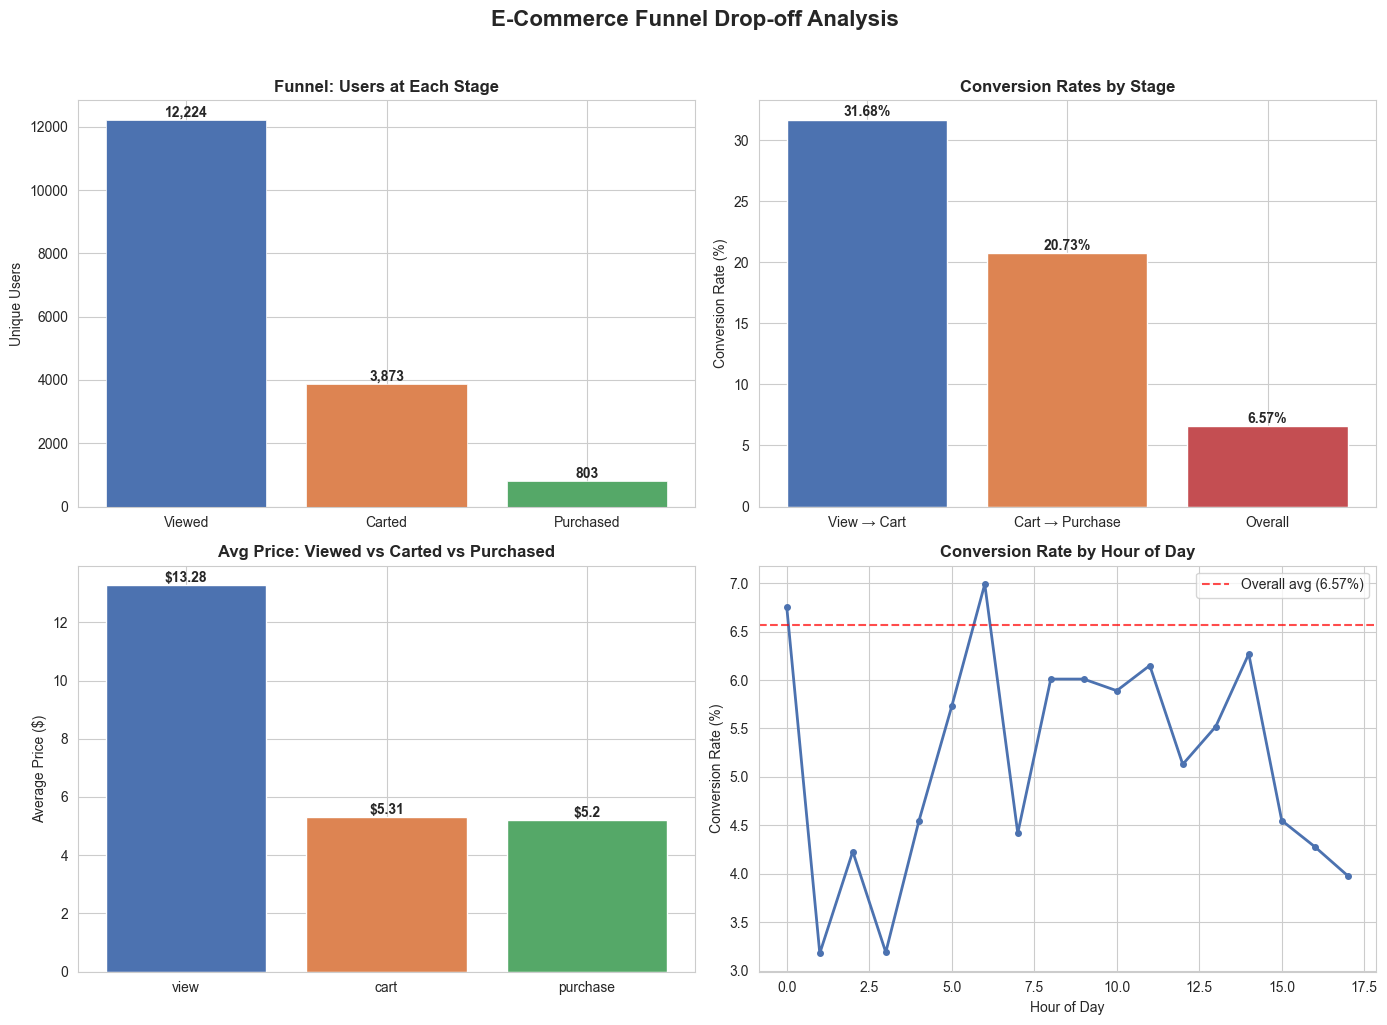

Chart saved!


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Set style
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('E-Commerce Funnel Drop-off Analysis', fontsize=16, fontweight='bold', y=1.02)

# --- Chart 1: Funnel Bar Chart ---
stages = ['Viewed', 'Carted', 'Purchased']
users = [12224, 3873, 803]
colors = ['#4C72B0', '#DD8452', '#55A868']

axes[0,0].bar(stages, users, color=colors, edgecolor='white', linewidth=0.5)
axes[0,0].set_title('Funnel: Users at Each Stage', fontweight='bold')
axes[0,0].set_ylabel('Unique Users')
for i, v in enumerate(users):
    axes[0,0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# --- Chart 2: Conversion Rates ---
conv_stages = ['View → Cart', 'Cart → Purchase', 'Overall']
conv_rates = [31.68, 20.73, 6.57]

bars = axes[0,1].bar(conv_stages, conv_rates, color=['#4C72B0', '#DD8452', '#c44e52'], edgecolor='white')
axes[0,1].set_title('Conversion Rates by Stage', fontweight='bold')
axes[0,1].set_ylabel('Conversion Rate (%)')
for i, v in enumerate(conv_rates):
    axes[0,1].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')

# --- Chart 3: Avg Price by Event Type ---
price_data = df[df['event_type'].isin(['view','cart','purchase'])].groupby('event_type')['price'].mean().round(2)
price_data = price_data.reindex(['view', 'cart', 'purchase'])

axes[1,0].bar(price_data.index, price_data.values, color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white')
axes[1,0].set_title('Avg Price: Viewed vs Carted vs Purchased', fontweight='bold')
axes[1,0].set_ylabel('Average Price ($)')
for i, v in enumerate(price_data.values):
    axes[1,0].text(i, v + 0.1, f'${v}', ha='center', fontweight='bold')

# --- Chart 4: Hourly Conversion Rate ---
hourly_conv = df.groupby(['hour', 'event_type'])['user_id'].nunique().unstack().fillna(0)
hourly_conv['conversion_rate'] = (hourly_conv['purchase'] / hourly_conv['view'] * 100).round(2)

axes[1,1].plot(hourly_conv.index, hourly_conv['conversion_rate'], 
               color='#4C72B0', linewidth=2, marker='o', markersize=4)
axes[1,1].set_title('Conversion Rate by Hour of Day', fontweight='bold')
axes[1,1].set_ylabel('Conversion Rate (%)')
axes[1,1].set_xlabel('Hour of Day')
axes[1,1].axhline(y=6.57, color='red', linestyle='--', alpha=0.7, label='Overall avg (6.57%)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('C:/Users/yashi gill/Desktop/funnel-dropoff-analysis/visuals/funnel_analysis.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")